<a href="https://colab.research.google.com/github/Madhura-55/IoT-Time-Series-Anomaly-Detection-using-Diffusion-Model-on-Smart-Grid-Data/blob/main/IoT_Time_Series_Anomaly_Detection_Diffusion_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler

import os
import zipfile


!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00321/LD2011_2014.txt.zip


with zipfile.ZipFile("LD2011_2014.txt.zip", 'r') as zip_ref:
    zip_ref.extractall()


df = pd.read_csv("LD2011_2014.txt", sep=';')


print(df.shape)
df.head()

/tmp/ipykernel_3919/1809252398.py:22: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,125,126,127,128,129,130,131,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,157,160,164,165,167,170,173,177,178,179,181,184,185,186,223,224,255,280,289,305,308,322,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,363,364,365,366,367,368,369,370) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("LD2011_2014.txt", sep=';')


(140256, 371)


,Unnamed: 0,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
0,2011-01-01 00:15:00,0,0,0,0,0,0,0,0,0,...,0,0.0,0,0,0,0,0,0,0,0
1,2011-01-01 00:30:00,0,0,0,0,0,0,0,0,0,...,0,0.0,0,0,0,0,0,0,0,0
2,2011-01-01 00:45:00,0,0,0,0,0,0,0,0,0,...,0,0.0,0,0,0,0,0,0,0,0
3,2011-01-01 01:00:00,0,0,0,0,0,0,0,0,0,...,0,0.0,0,0,0,0,0,0,0,0
4,2011-01-01 01:15:00,0,0,0,0,0,0,0,0,0,...,0,0.0,0,0,0,0,0,0,0,0


In [31]:
df.rename(columns={df.columns[0]: "datetime"}, inplace=True)
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

df = df.replace(',', '.', regex=True)
df = df.astype(float)

print(df.shape)
df.head(15)

(140256, 370)


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 02:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
df.isnull().sum(axis=1)

,0
datetime,
2011-01-01 00:15:00,0
2011-01-01 00:30:00,0
2011-01-01 00:45:00,0
2011-01-01 01:00:00,0
2011-01-01 01:15:00,0
...,...
2014-12-31 23:00:00,0
2014-12-31 23:15:00,0
2014-12-31 23:30:00,0


In [33]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 140256 entries, 2011-01-01 00:15:00 to 2015-01-01 00:00:00
Columns: 370 entries, MT_001 to MT_370
dtypes: float64(370)
memory usage: 397.0 MB
None


In [16]:
df.describe()

,MT_001,MT_002,MT_003,MT_004,MT_005
count,20000.0,20000.0,20000.0,20000.0,20000.0
mean,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0


so now for the dataset I want to train for different range in dataset ?

In [49]:
df_sample = df.iloc[:2000]

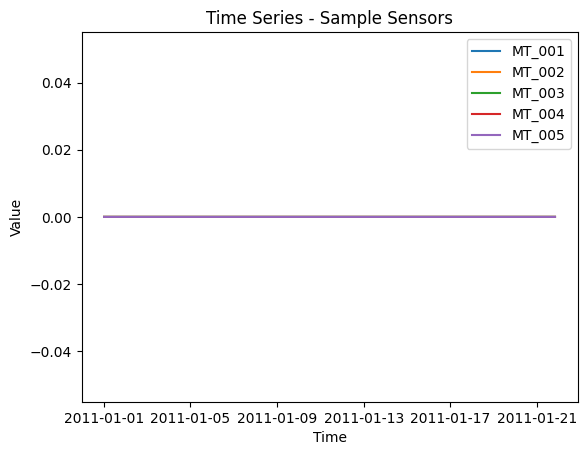

In [50]:
cols = df.columns[:5]

plt.figure()
for col in cols:
    plt.plot(df_sample.index, df_sample[col], label=col)

plt.legend()
plt.title("Time Series - Sample Sensors")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

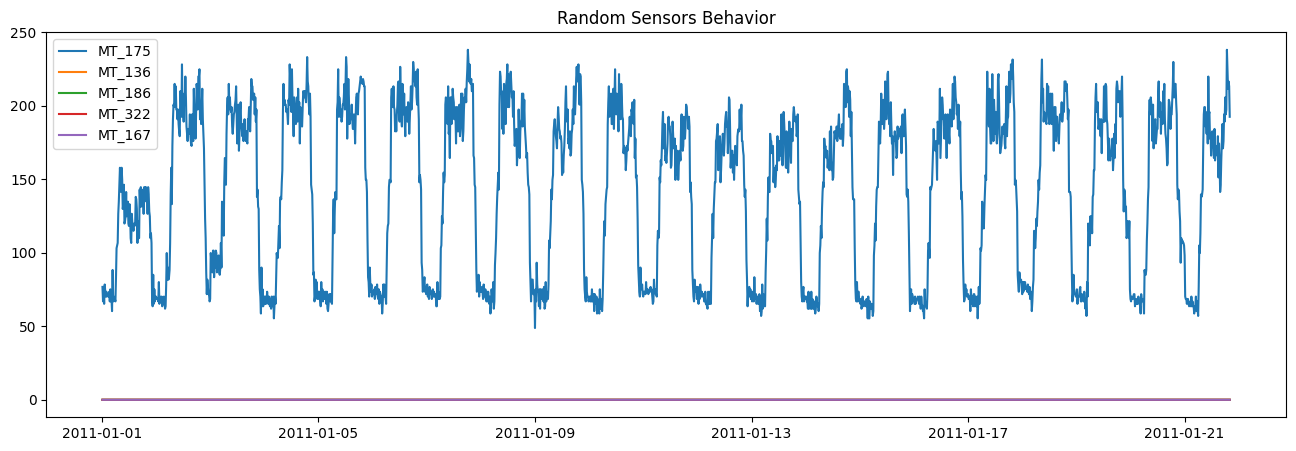

In [51]:
import random
random_cols = random.sample(list(df.columns), 5)

plt.figure(figsize=(16, 5))
for col in random_cols:
    plt.plot(df_sample.index, df_sample[col], label=col)

plt.legend()
plt.title("Random Sensors Behavior")

plt.show()

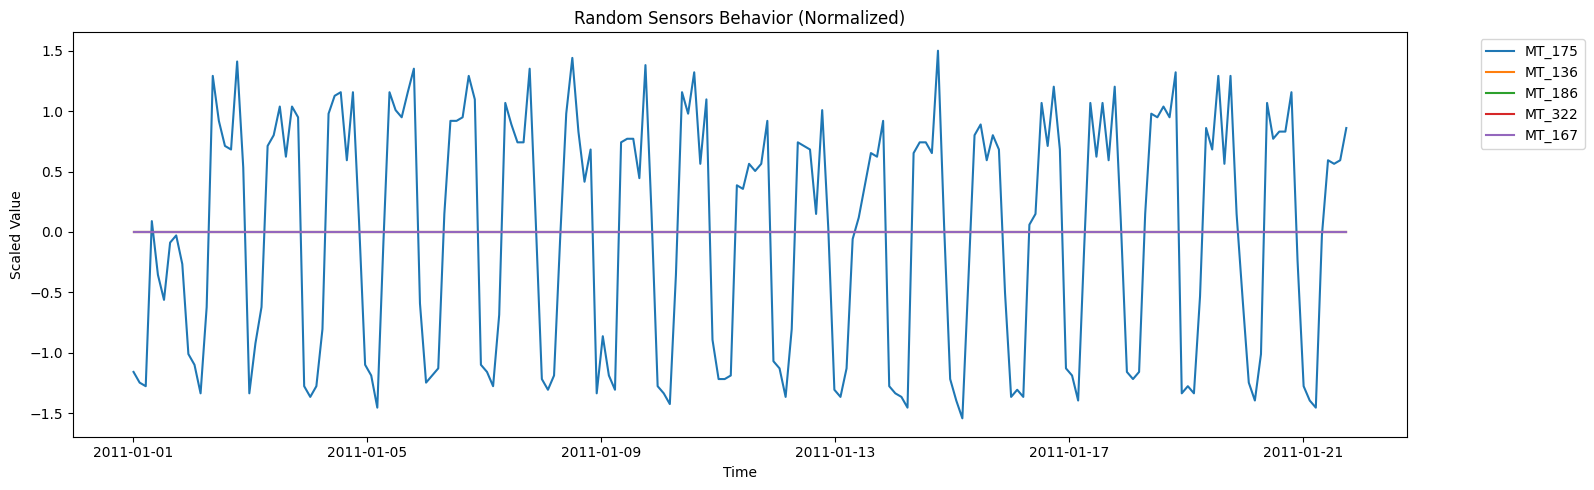

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df_sample),
    columns=df.columns,
    index=df_sample.index
)

df_plot = df_scaled.iloc[::10]

plt.figure(figsize=(16, 5))

for col in random_cols:
    plt.plot(df_plot.index, df_plot[col], label=col)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Random Sensors Behavior (Normalized)")
plt.xlabel("Time")
plt.ylabel("Scaled Value")

plt.tight_layout()
plt.show()

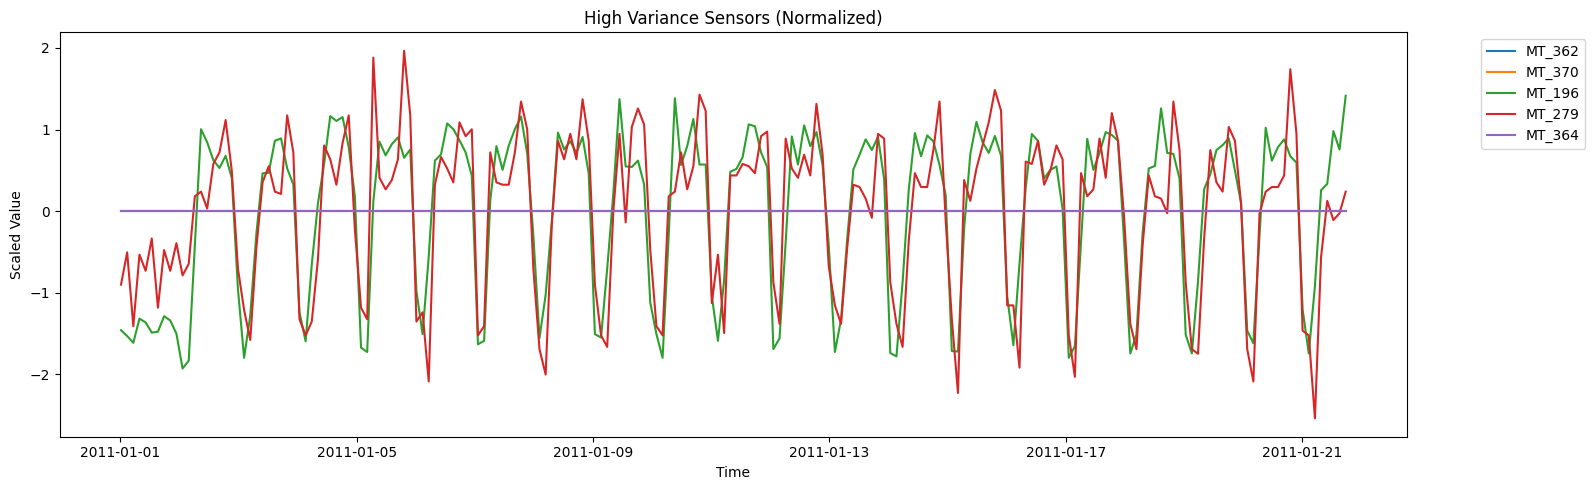

In [59]:
high_var_cols = df.var().sort_values(ascending=False).head(5).index

df_plot = df_scaled.iloc[::10]

plt.figure(figsize=(16, 5))

for col in high_var_cols:
    plt.plot(df_plot.index, df_plot[col], label=col)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("High Variance Sensors (Normalized)")
plt.xlabel("Time")
plt.ylabel("Scaled Value")

plt.tight_layout()
plt.show()

In [60]:
low_var = df.var()

# sensors with very low variance
low_var_cols = low_var[low_var < 1e-3].index

print("Number of low variance sensors:", len(low_var_cols))

Number of low variance sensors: 0


In [61]:
var = df.var()

print(var.describe())

count    3.700000e+02
mean     4.574623e+06
std      7.797852e+07
min      5.111116e+00
25%      8.923989e+02
50%      3.335923e+03
75%      1.685007e+04
max      1.497067e+09
dtype: float64
